<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Top_2000_Highest_Rated_TV_Shows_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Top 2000 Highest-Rated TV Shows Dataset


# About the dataset

This dataset comprises the "Top 2000 Highest-Rated TV Shows," offering a comprehensive look into popular series with 2000 entries and 11 distinct features. Each entry provides details such as a unique `id`, `title`, `original_title`, `overview`, `premiere_date`, `popularity` score, `genre` classifications, `country_origin`, `original_language`, `rating`, and `votes` count.

Initial data inspection revealed a clean dataset with no duplicate rows. However, minor missing values were identified in the `overview` column (20 entries) and `country_origin` (1 entry), which is a common occurrence in real-world data and might need further handling depending on the analytical goals.

Univariate analysis highlighted several interesting distributions:
*   **Ratings** are generally high, clustering between 7.0 and 8.9, reflecting the dataset's focus on "highest-rated" shows. The mean rating is approximately 7.85.
*   **Popularity** and **votes** exhibit a right-skewed distribution, indicating a few highly popular shows with a large number of votes, while the majority have moderate values.
*   **Genre** analysis shows 'Drama' as the most prevalent category, often combined with 'Crime' or 'Comedy'.
*   The **United States** dominates as the primary `country_origin`, followed by Japan, reflecting major production hubs for TV content. **English** is overwhelmingly the most common `original_language`.

Bivariate analysis provided insights into relationships between features:
*   A strong positive correlation was observed between `rating` and `votes`, suggesting that highly-rated shows tend to attract more viewers and, consequently, more votes. `popularity` also shows a positive, albeit weaker, correlation with `rating` and `votes`.
*   Box plots revealed how `rating` and `popularity` vary across different genres, countries, and languages, indicating potential preferences or market trends associated with specific categories.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d raveennimbiwal/top-rated-tv-shows-dataset-global-2025

# Unziping the downloaded file
!unzip top-rated-tv-shows-dataset-global-2025.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/raveennimbiwal/top-rated-tv-shows-dataset-global-2025
License(s): CC0-1.0
  0% 0.00/314k [00:00<?, ?B/s]
100% 314k/314k [00:00<00:00, 697MB/s]
Archive:  top-rated-tv-shows-dataset-global-2025.zip
  inflating: top_rated_2000webseries.csv  


In [5]:
df = pd.read_csv('top_rated_2000webseries.csv')
df.head(11)

,id,title,original_title,overview,premiere_date,popularity,genre,country_origin,original_language,rating,votes
0,1,Breaking Bad,Breaking Bad,"Walter White, a New Mexico chemistry teacher, ...",2008-01-20,108.7820,"Drama, Crime",United States,English,8.900,16556
1,2,Avatar: The Last Airbender,Avatar: The Last Airbender,"In a war-torn world of elemental magic, a youn...",2005-02-21,12.5347,"Animation, Action & Adventure, Sci-Fi & Fantasy",United States,English,8.800,4557
2,3,Arcane,Arcane,Amid the stark discord of twin cities Piltover...,2021-11-06,22.5739,"Animation, Sci-Fi & Fantasy, Drama, Action & A...",United States,English,8.800,5481
3,4,When Life Gives You Tangerines,폭싹 속았수다,"In Jeju, a spirited girl and a steadfast boy's...",2025-03-07,18.5771,Drama,South Korea,Korean,8.751,423
4,5,Frieren: Beyond Journey's End,葬送のフリーレン,Decades after her party defeated the Demon Kin...,2023-09-29,28.3761,"Animation, Action & Adventure, Drama, Sci-Fi &...",Japan,Japanese,8.735,565
5,6,One Piece,ワンピース,"Years ago, the fearsome Pirate King, Gol D. Ro...",1999-10-20,31.2270,"Action & Adventure, Comedy, Animation",Japan,Japanese,8.700,5043
6,7,Fullmetal Alchemist: Brotherhood,鋼の錬金術師 FULLMETAL ALCHEMIST,Disregard for alchemy’s laws ripped half of Ed...,2009-04-05,15.9934,"Animation, Action & Adventure, Sci-Fi & Fantas...",Japan,Japanese,8.700,2291
7,8,The Chosen,The Chosen,The life of Christ through the eyes of those w...,2019-04-21,33.9177,"Drama, Family, Action & Adventure",United States,English,8.700,689
8,9,Better Call Saul,Better Call Saul,Six years before Saul Goodman meets Walter Whi...,2015-02-08,37.4222,"Crime, Drama",United States,English,8.699,5992
9,10,Chernobyl,Chernobyl,The true story of one of the worst man-made ca...,2019-05-06,25.0952,Drama,United States,English,8.692,7275


In [6]:
df.tail(11)

,id,title,original_title,overview,premiere_date,popularity,genre,country_origin,original_language,rating,votes
1989,1990,Broad City,Broad City,Broad City follows two women throughout their ...,2014-01-22,8.4970,"Comedy, Drama",United States,English,7.100,226
1990,1991,Sesame Street,Sesame Street,"On a special inner city street, the inhabitant...",1969-11-10,33.2784,"Kids, Comedy",United States,English,7.100,272
1991,1992,Star Wars: Visions,Star Wars: Visions,This anthology of animated shorts from around ...,2021-09-22,11.8100,"Animation, Sci-Fi & Fantasy, Action & Adventure","Japan, United States",English,7.100,439
1992,1993,Crashing,Crashing,A comedy drama that crashes straight into the ...,2016-01-11,1.8026,"Comedy, Drama",United Kingdom,English,7.106,221
1993,1994,Bloodline,Bloodline,A dramatic thriller that explores the demons l...,2015-03-20,8.4655,Drama,United States,English,7.098,378
1994,1995,"Ringo, la pelea de su vida","Ringo, la pelea de su vida","Ringo is a young man, who has dedicated his li...",2019-01-23,1.3873,Drama,Mexico,Spanish,7.096,240
1995,1996,The Three Sides of Ana,Tres veces Ana,"Over a road trip, triplets Ana Laura, Ana Leti...",2016-05-23,2.7459,"Soap, Drama",Mexico,Spanish,7.091,328
1996,1997,Power Rangers,Power Rangers,A team of teenagers with attitude are recruite...,1993-08-28,10.9899,"Action & Adventure, Sci-Fi & Fantasy, Kids",United States,English,7.100,812
1997,1998,MasterChef,MasterChef,This hit cooking competition series sees award...,2010-07-27,10.9557,Reality,United States,English,7.090,282
1998,1999,I Am Georgina,Soy Georgina,"Join Georgina Rodríguez — mom, influencer, bus...",2022-01-27,2.6178,Reality,Spain,Spanish,7.100,319


In [7]:
df.shape

(2000, 11)

In [8]:
df.columns

Index(['id', 'title', 'original_title', 'overview', 'premiere_date',
       'popularity', 'genre', 'country_origin', 'original_language', 'rating',
       'votes'],
      dtype='object')

In [9]:
df.dtypes

,0
id,int64
title,object
original_title,object
overview,object
premiere_date,object
popularity,float64
genre,object
country_origin,object
original_language,object
rating,float64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   title              2000 non-null   object 
 2   original_title     2000 non-null   object 
 3   overview           1980 non-null   object 
 4   premiere_date      2000 non-null   object 
 5   popularity         2000 non-null   float64
 6   genre              2000 non-null   object 
 7   country_origin     1999 non-null   object 
 8   original_language  2000 non-null   object 
 9   rating             2000 non-null   float64
 10  votes              2000 non-null   int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 172.0+ KB


In [11]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,2000.0,NaN,NaN,NaN,1000.5,577.494589,1.0,500.75,1000.5,1500.25,2000.0
title,2000,1964,Teenage Mutant Ninja Turtles,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_title,2000,1966,キャプテン翼,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overview,1980,1979,A young private's assignment to capture army d...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
premiere_date,2000,1713,2019-05-31,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,2000.0,NaN,NaN,NaN,13.557146,18.447762,0.3921,4.8211,8.24785,15.177375,338.2498
genre,2000,483,Drama,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_origin,1999,66,United States,1065,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_language,2000,22,English,1265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,2000.0,NaN,NaN,NaN,7.851328,0.414621,7.086,7.5,7.825,8.2,8.9


In [12]:
df.isnull().sum()

,0
id,0
title,0
original_title,0
overview,20
premiere_date,0
popularity,0
genre,0
country_origin,1
original_language,0
rating,0


In [13]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

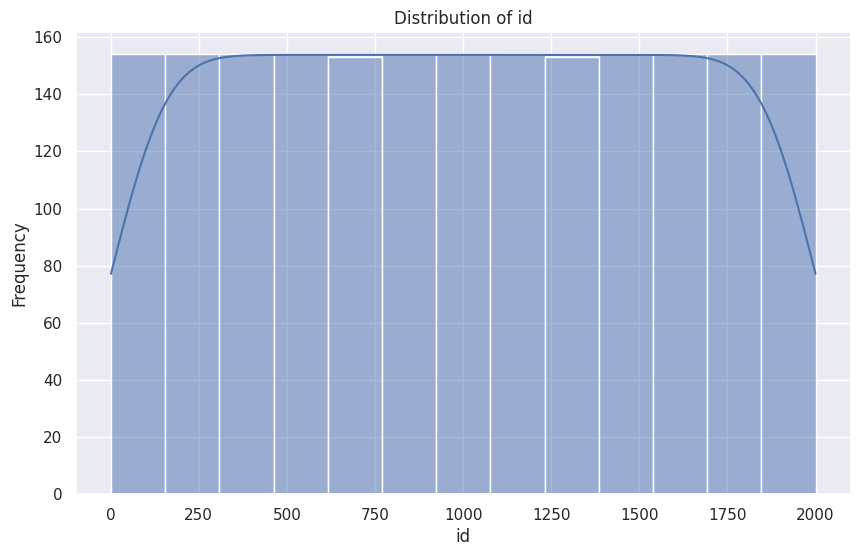

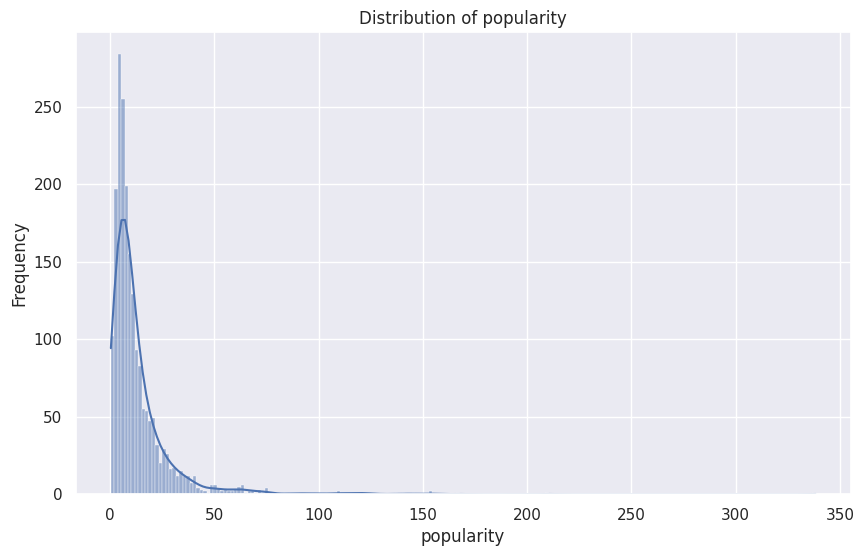

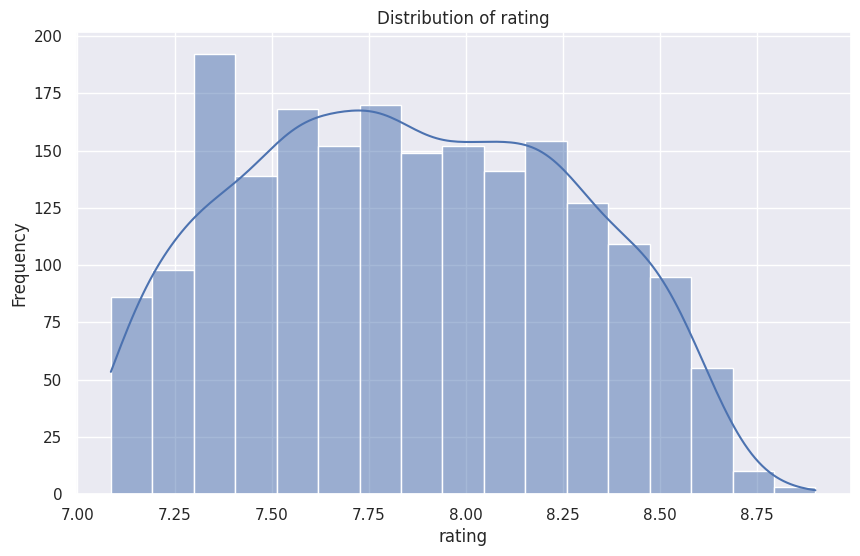

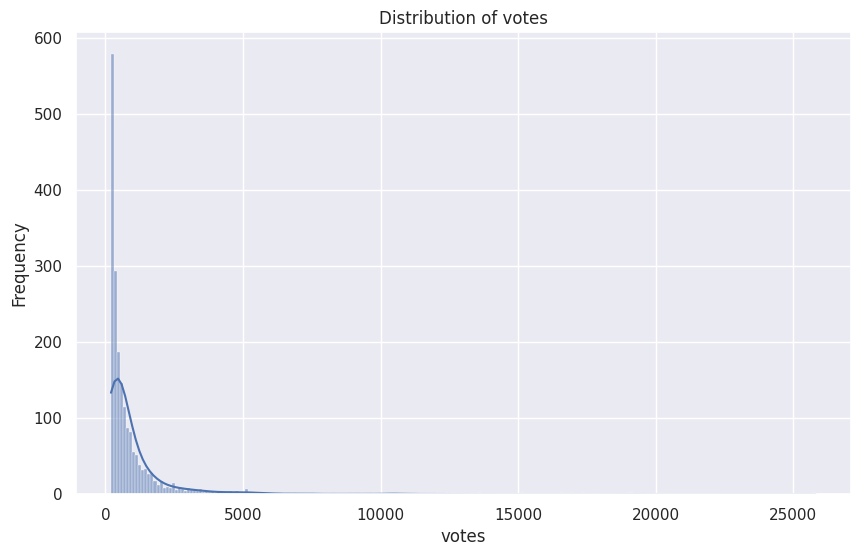

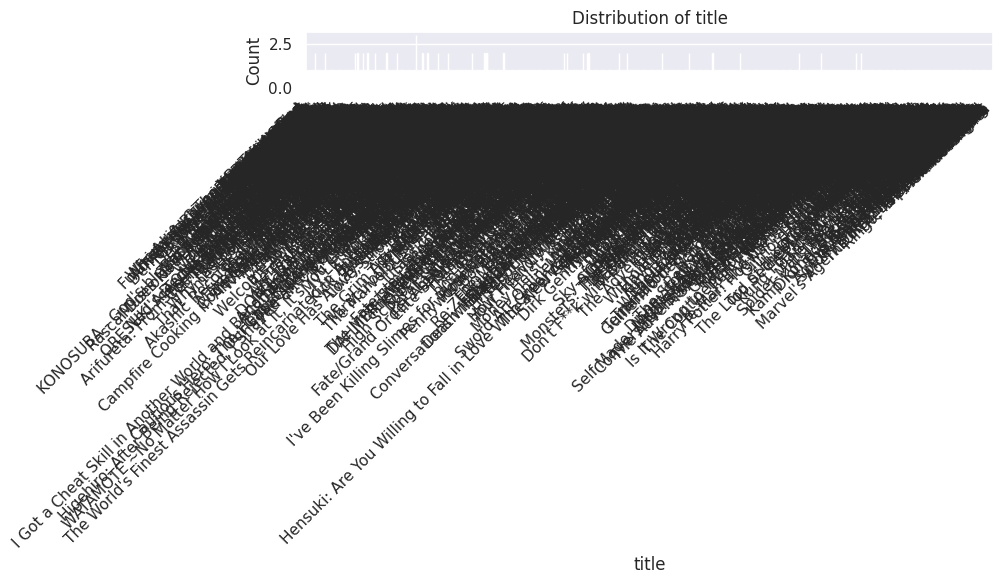

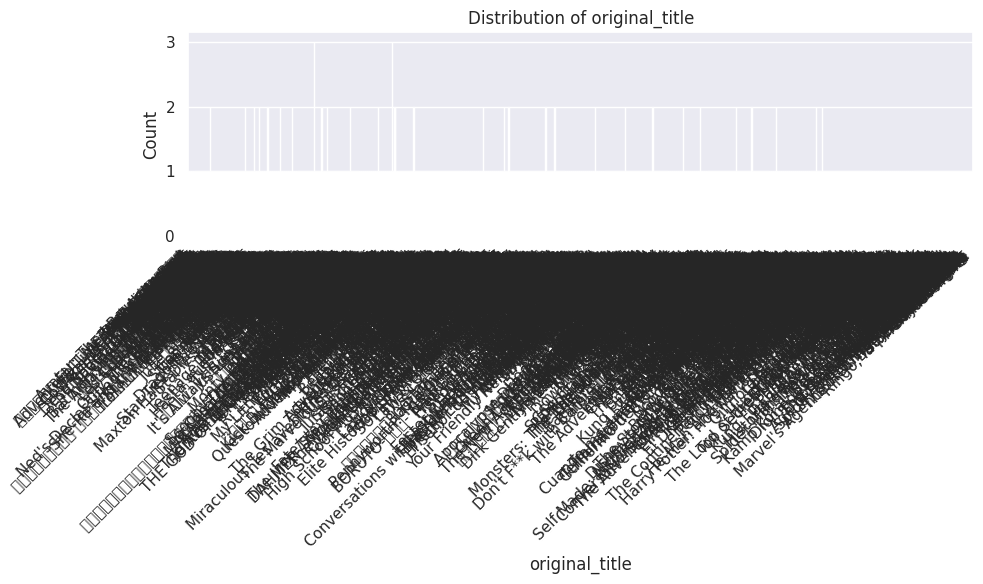

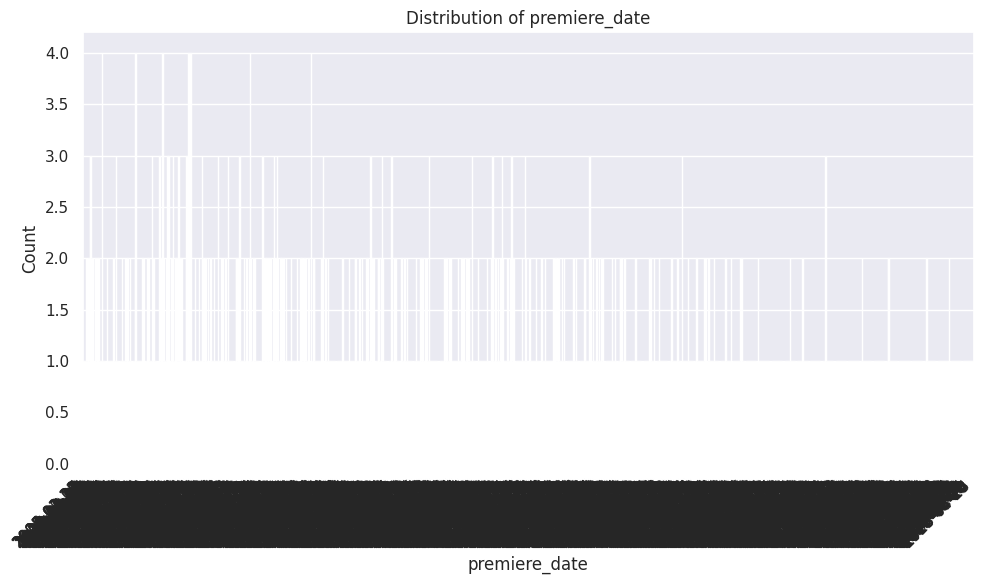

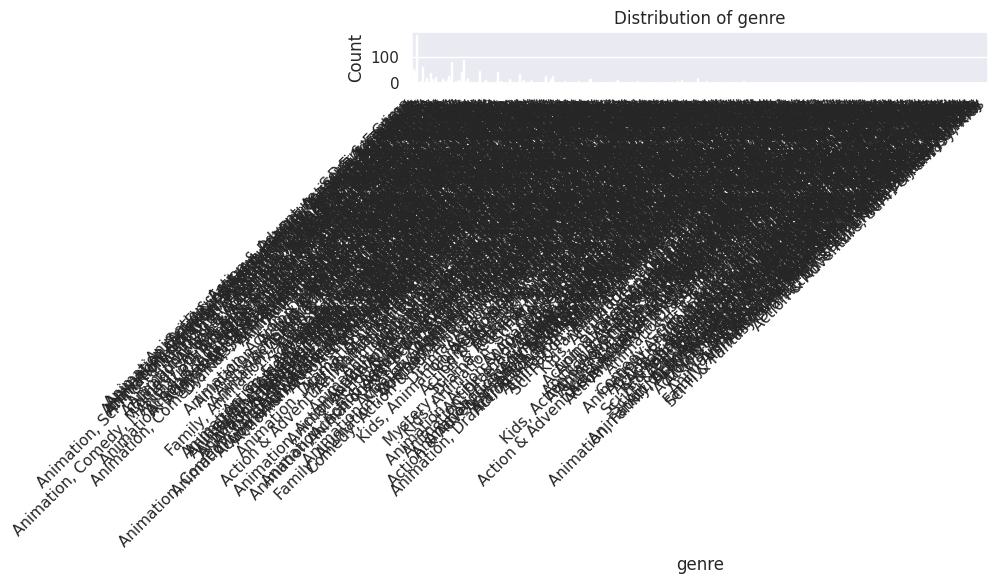

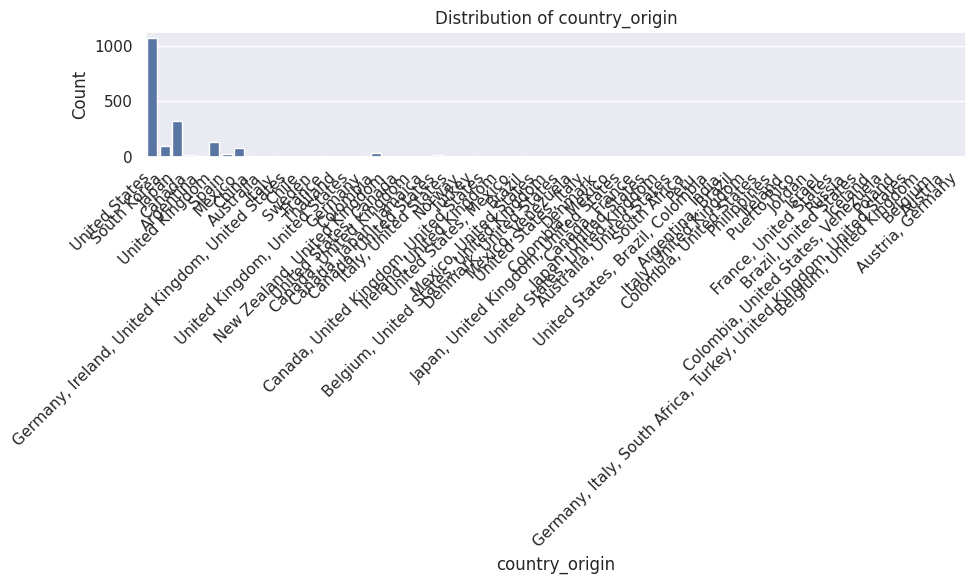

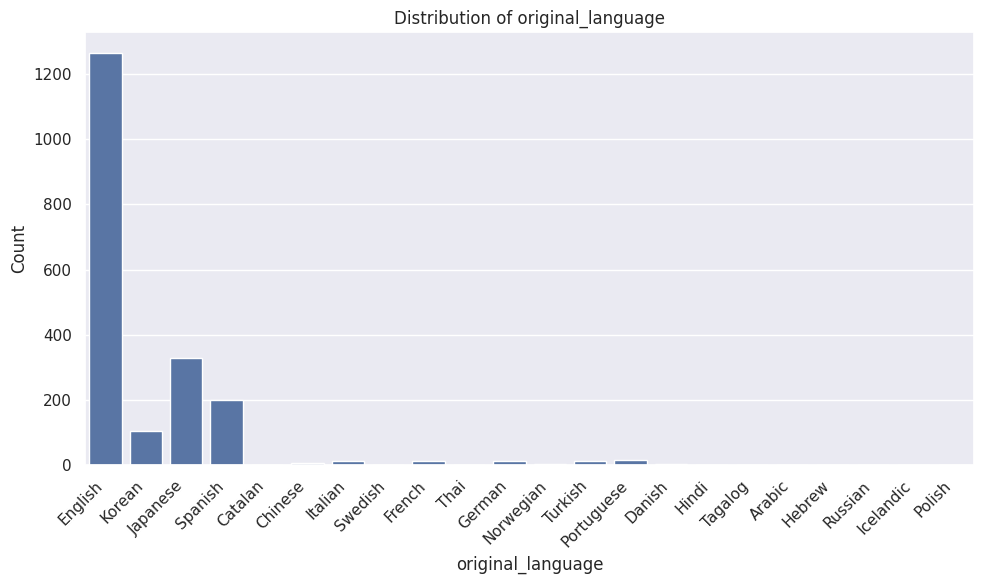

Value counts for title:
title
Teenage Mutant Ninja Turtles    3
The Office                      2
Vecinos                         2
Mission: Impossible             2
Doctor Who                      2
                               ..
Black Bird                      1
Everybody Hates Chris           1
The Nanny                       1
What If...?                     1
Destined with You               1
Name: count, Length: 1964, dtype: int64

Value counts for original_title:
original_title
キャプテン翼                          3
Teenage Mutant Ninja Turtles    3
Battlestar Galactica            2
Rebelde                         2
Rubí                            2
                               ..
Black Bird                      1
Everybody Hates Chris           1
The Nanny                       1
What If...?                     1
이 연애는 불가항력                      1
Name: count, Length: 1966, dtype: int64

Value counts for overview:
overview
A young private's assignment to capture army deserters r

In [16]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Exclude 'overview' from categorical_cols for countplots as it contains long text and special characters
categorical_cols_for_countplot = [col for col in categorical_cols if col != 'overview']

# Iterate through categorical columns and create countplots
for col in categorical_cols_for_countplot:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

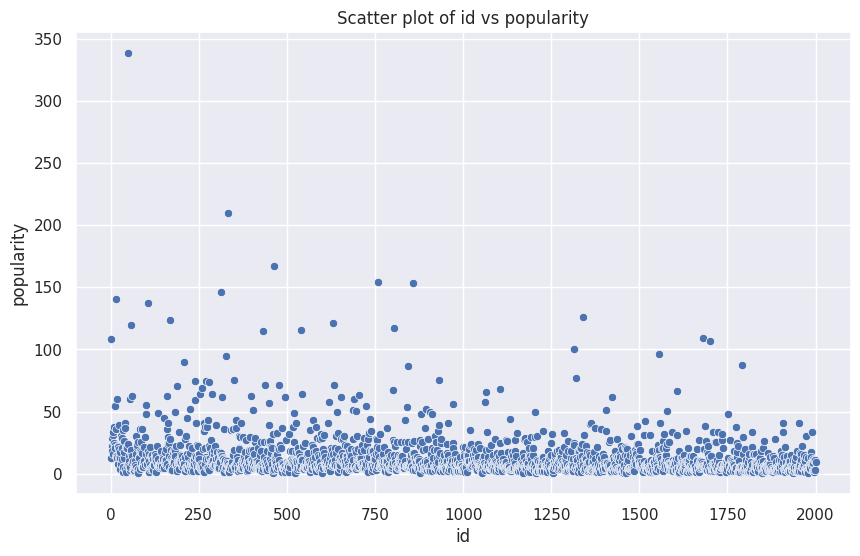

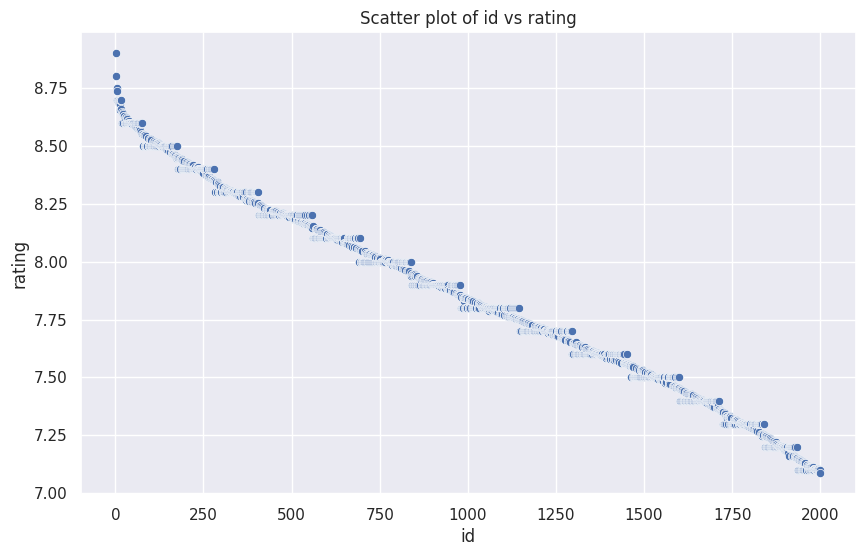

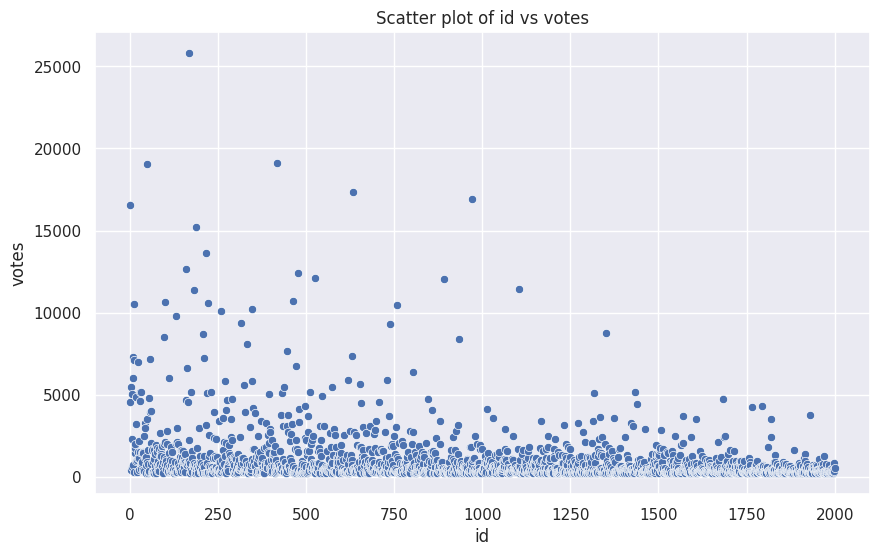

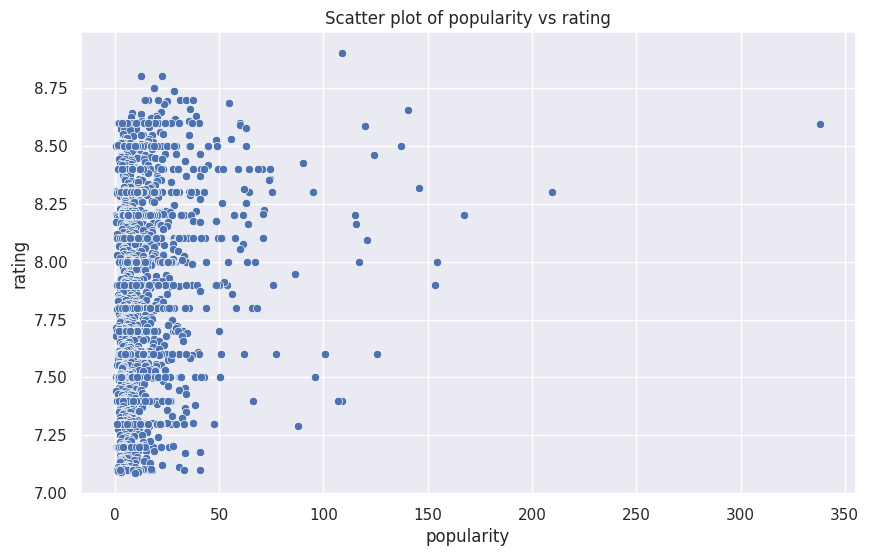

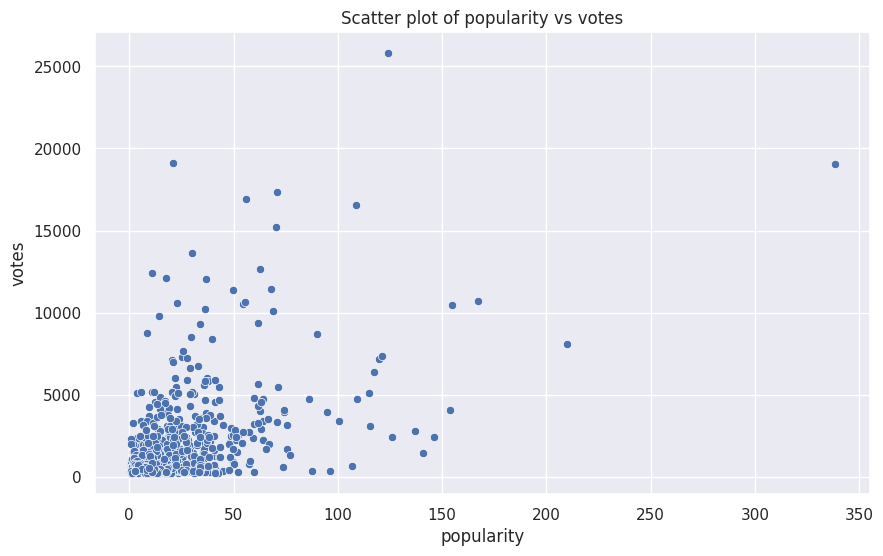

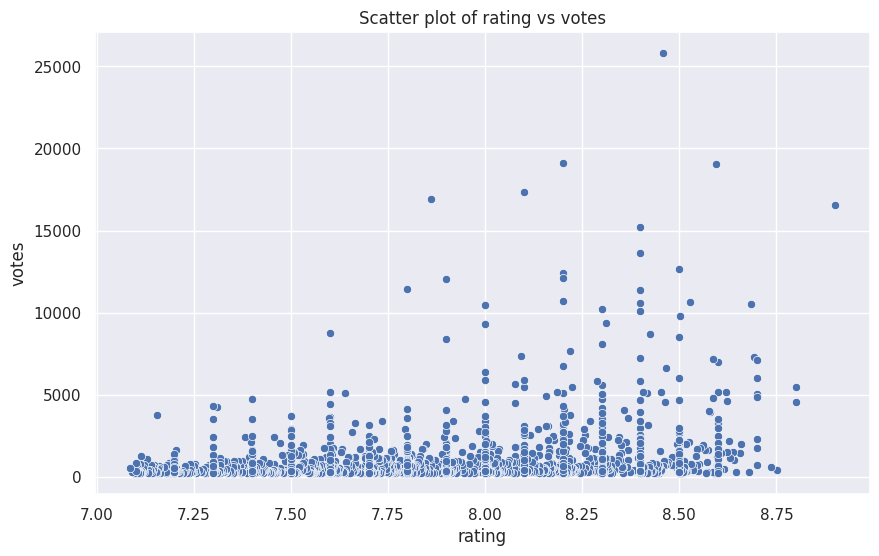

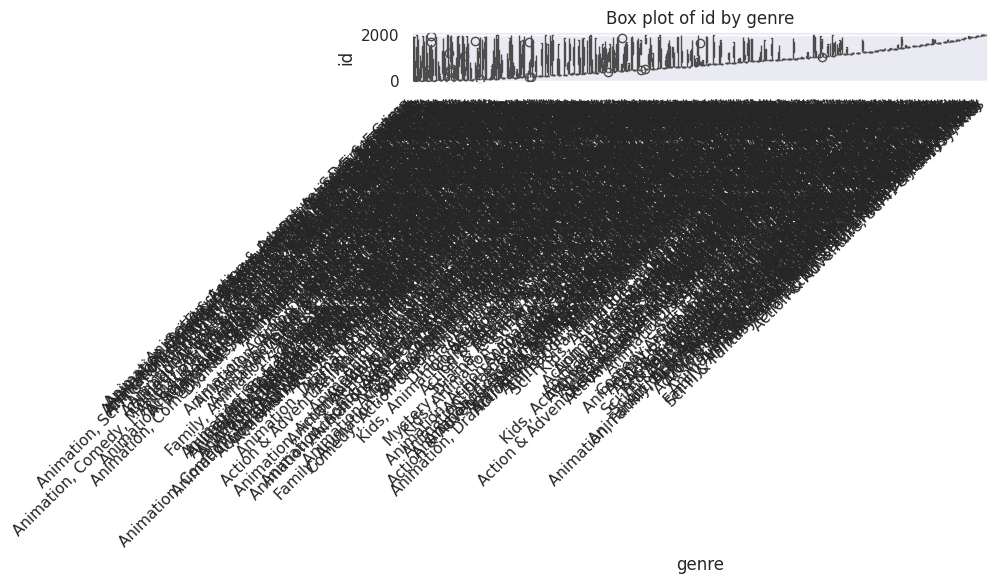

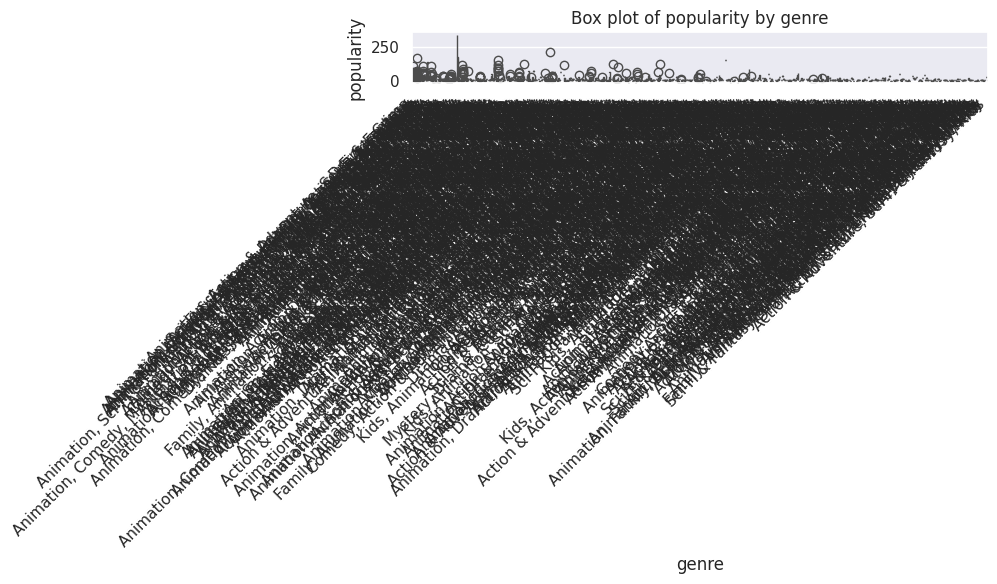

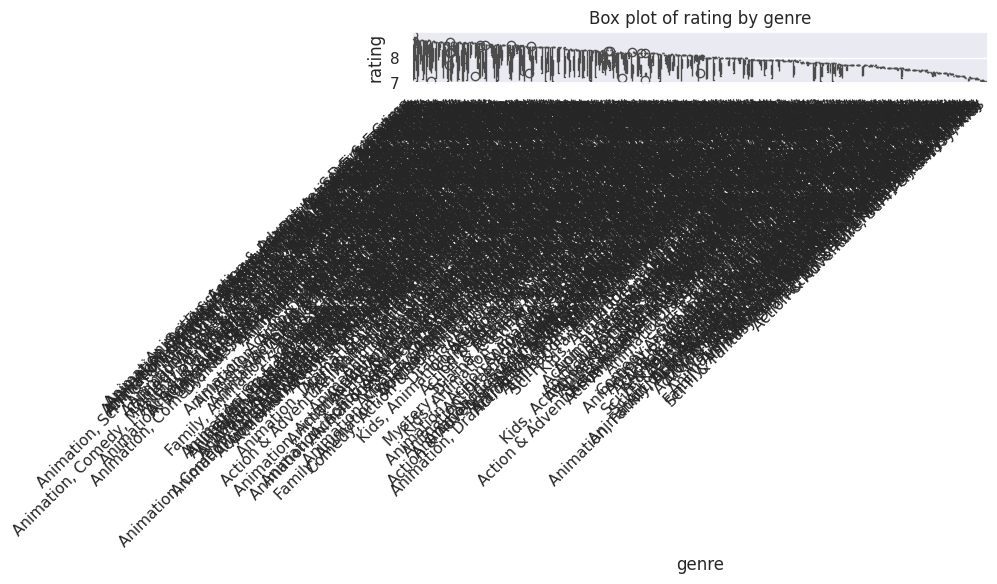

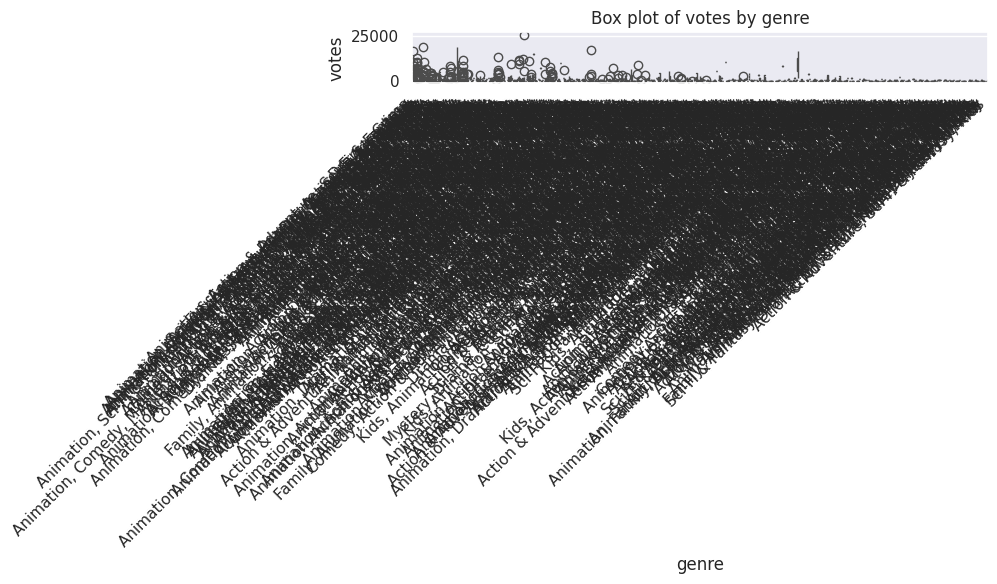

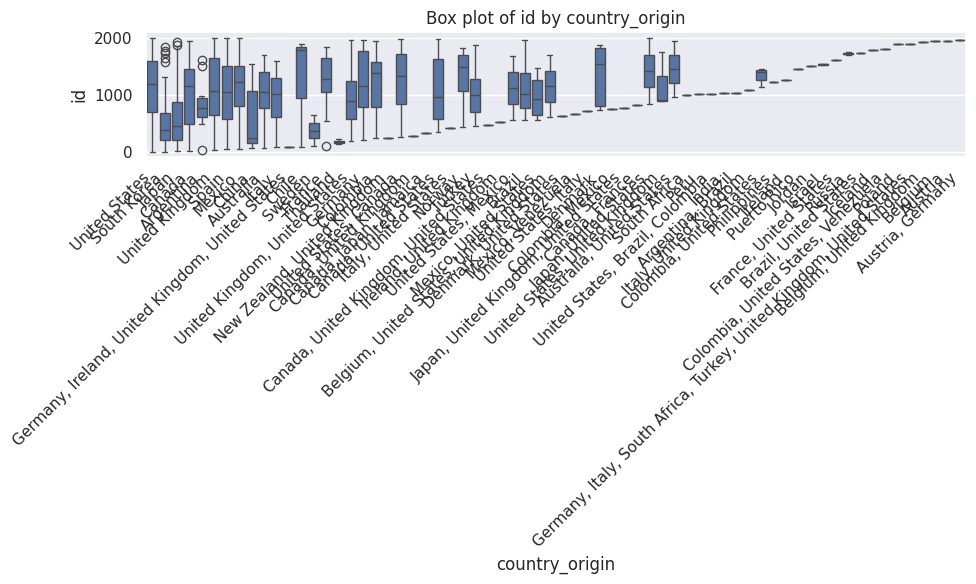

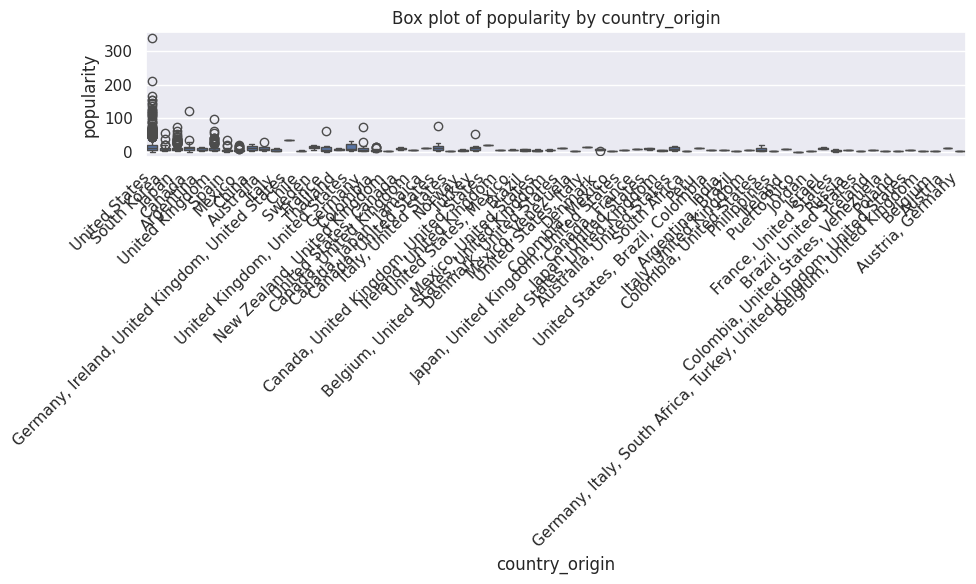

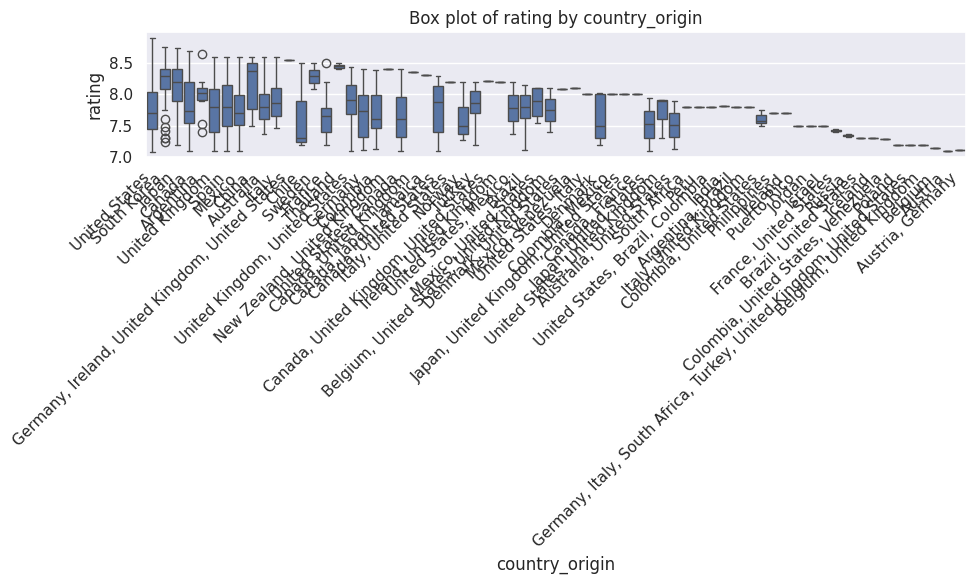

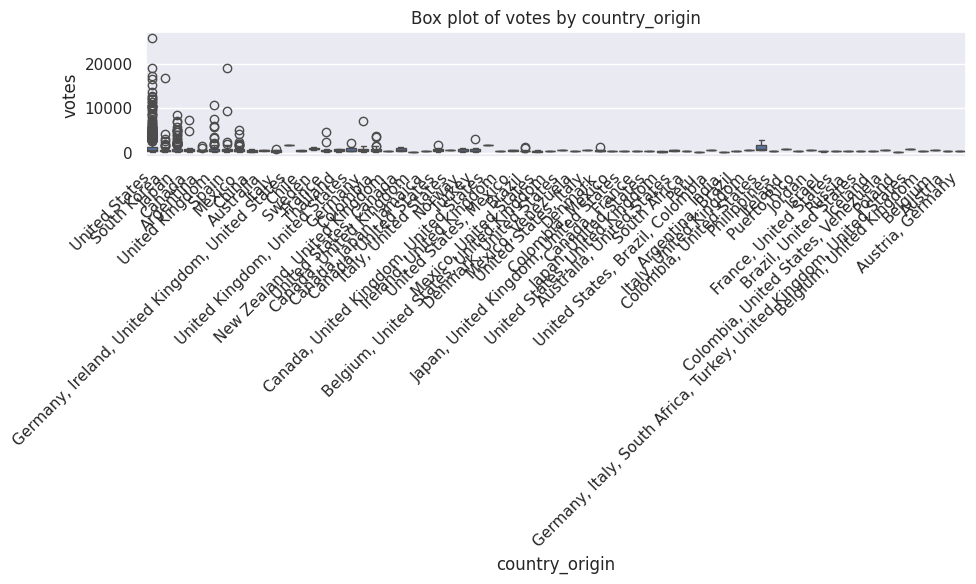

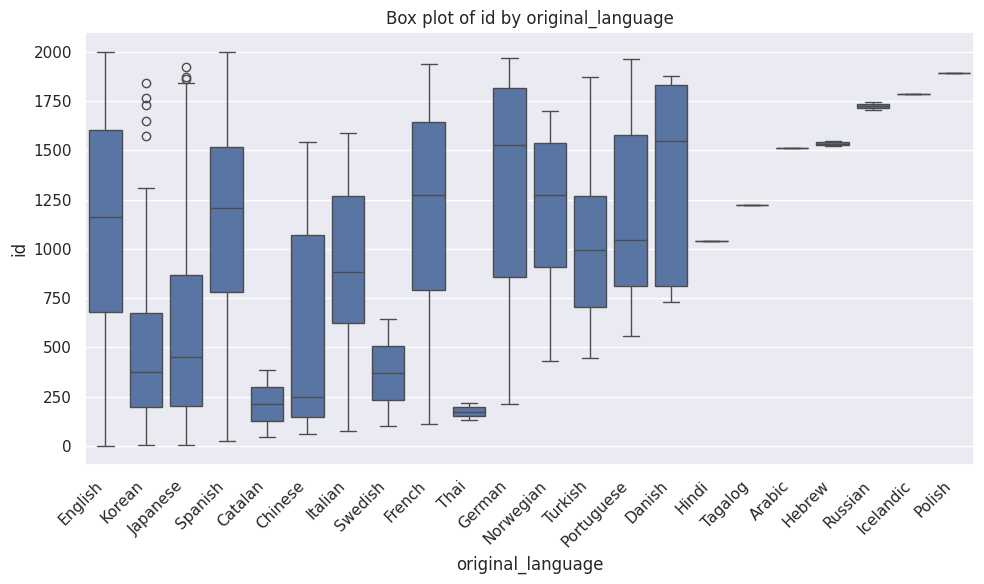

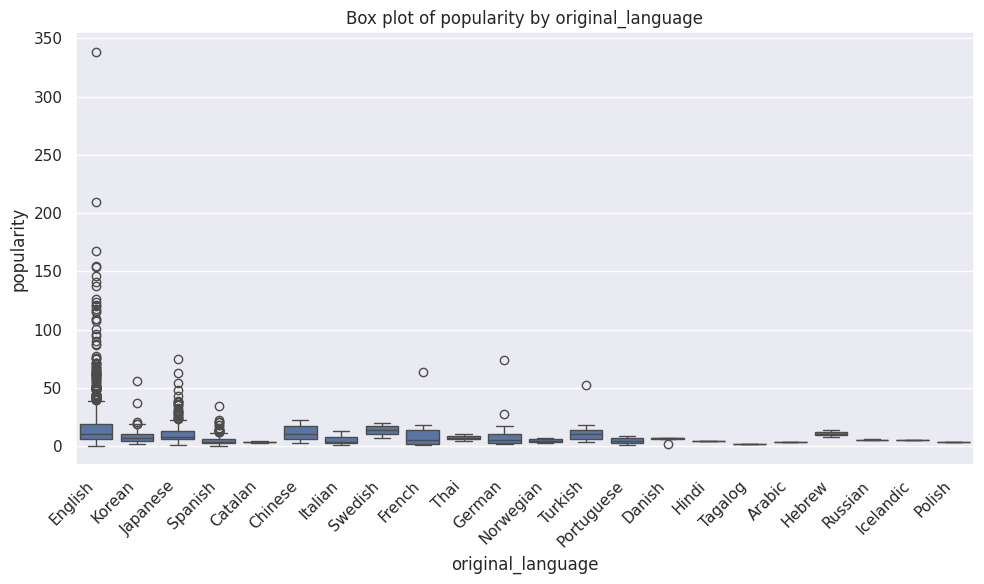

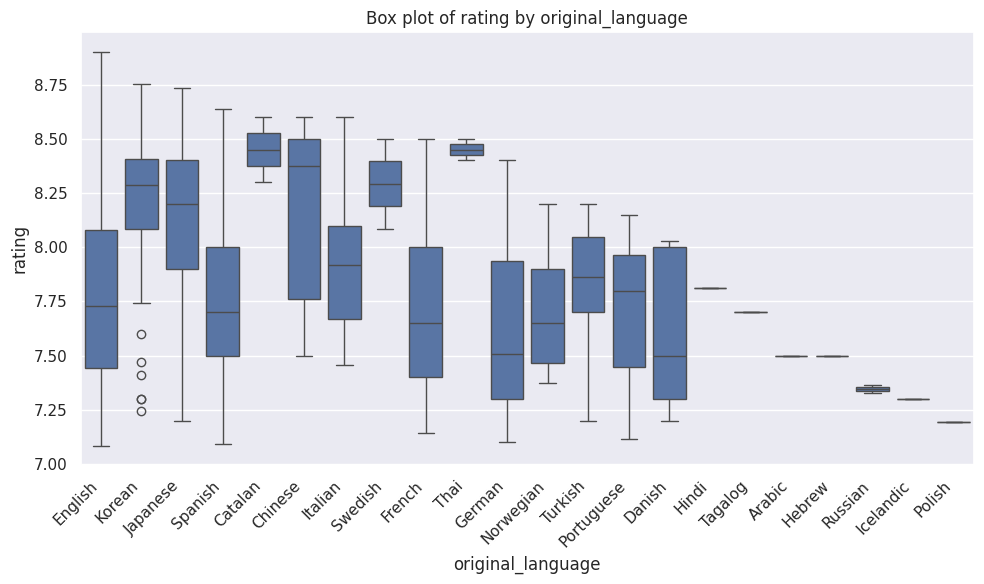

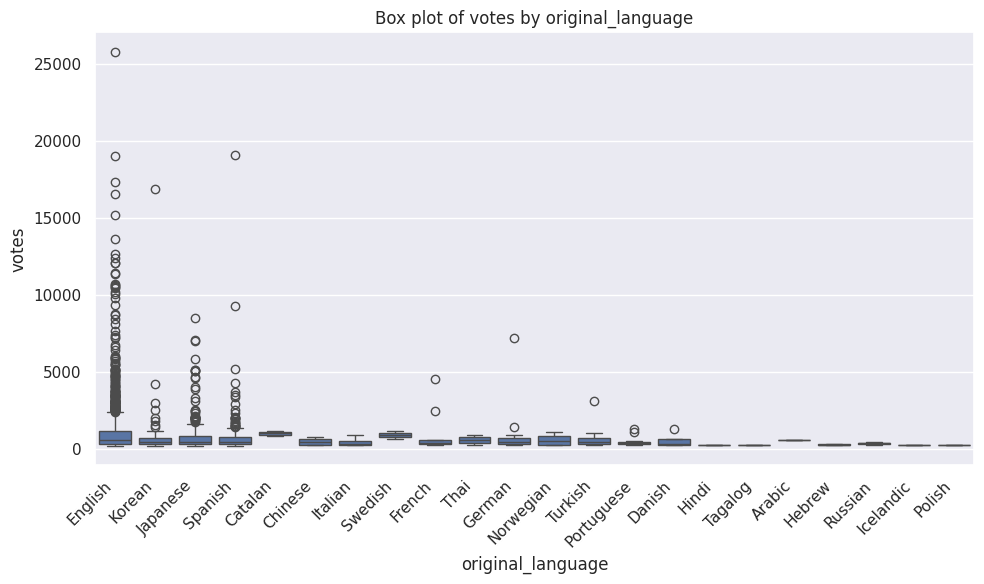

In [19]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Exclude high-cardinality columns that are not suitable for box plots
cols_to_exclude_from_boxplot = ['title', 'original_title', 'overview', 'premiere_date']
filtered_categorical_cols = [col for col in categorical_cols if col not in cols_to_exclude_from_boxplot]

# Iterate through filtered categorical and numerical columns and create box plots
for cat_col in filtered_categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

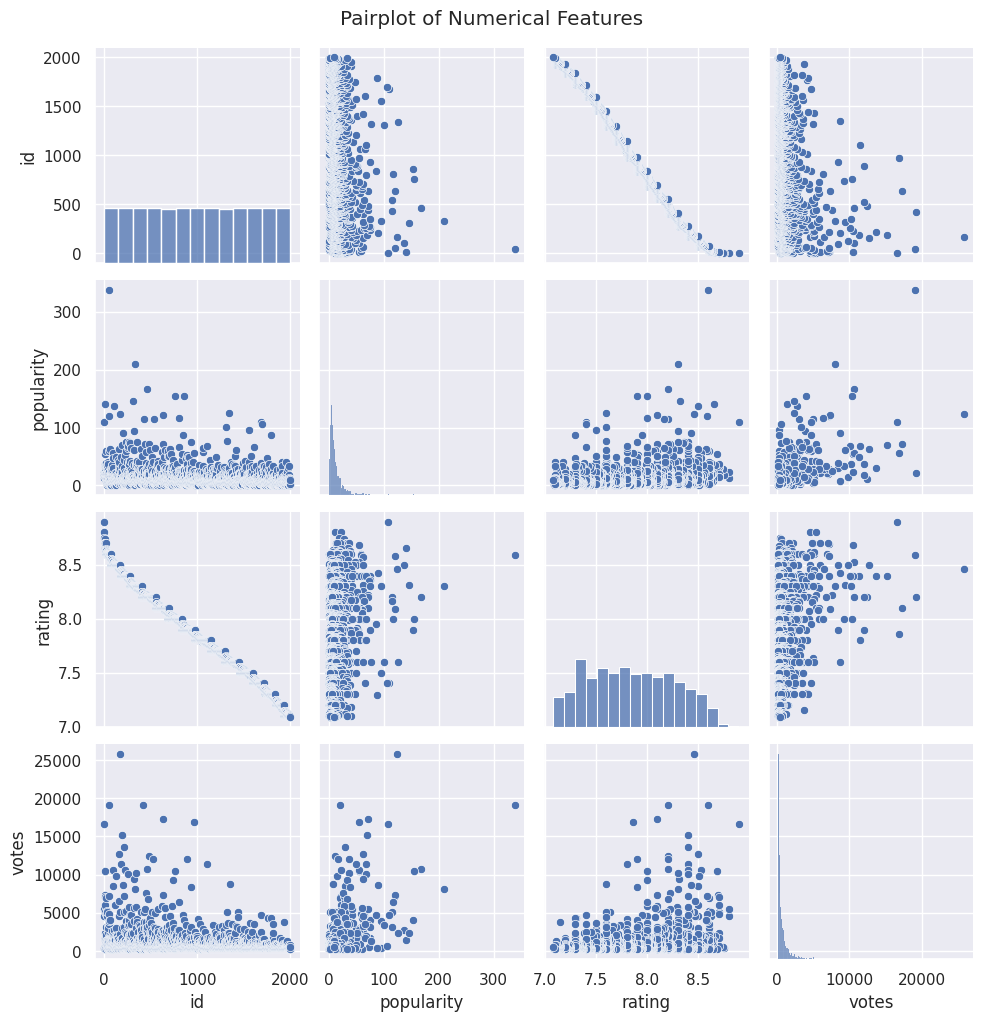

In [17]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

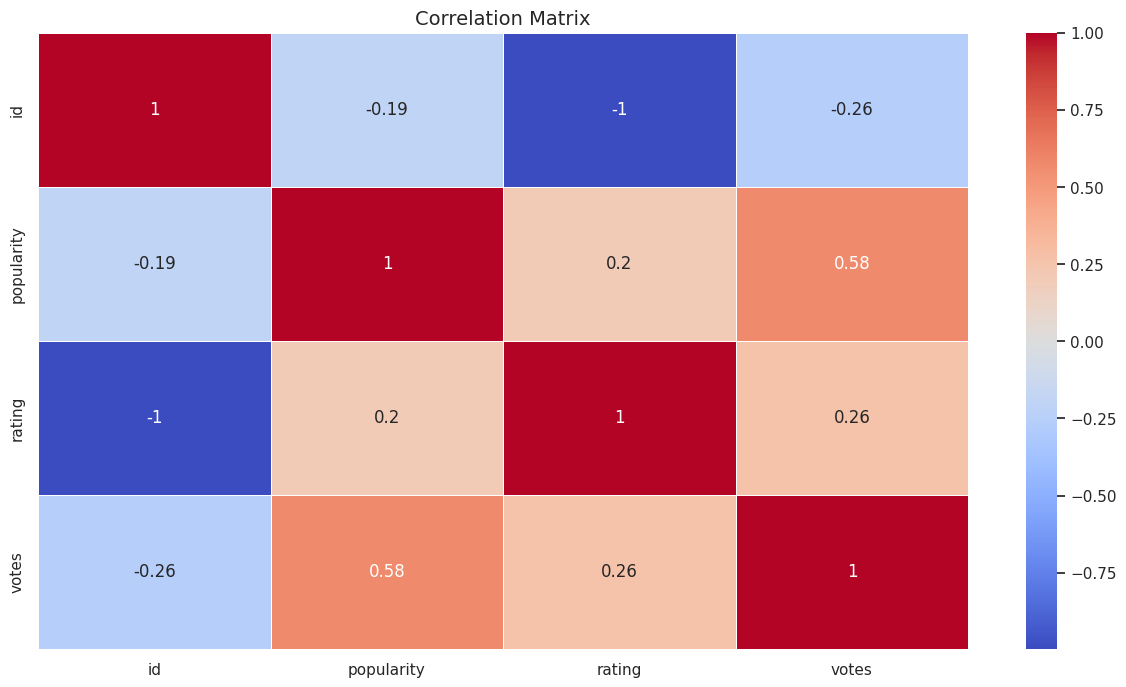

In [18]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You